In [1]:
import pandas as pd
import numpy as np

In [3]:
train_data=pd.read_csv('train.csv/train.csv')

In [4]:
train_data.head()

,Date,store,product,number_sold
0,2010-01-01,0,0,801
1,2010-01-02,0,0,810
2,2010-01-03,0,0,818
3,2010-01-04,0,0,796
4,2010-01-05,0,0,808


In [6]:
test_data=pd.read_csv('test.csv')

In [7]:
test_data.sample(3)

,Date,store,product,number_sold
11062,2019-04-23,3,0,283
16968,2019-06-28,4,6,1000
11834,2019-06-04,3,2,339


In [8]:
tdf=train_data.loc[(train_data['store']==0)&(train_data['product']==0)].copy()

In [9]:
tdf

,Date,store,product,number_sold
0,2010-01-01,0,0,801
1,2010-01-02,0,0,810
2,2010-01-03,0,0,818
3,2010-01-04,0,0,796
4,2010-01-05,0,0,808
...,...,...,...,...
3282,2018-12-27,0,0,847
3283,2018-12-28,0,0,854
3284,2018-12-29,0,0,839
3285,2018-12-30,0,0,847


In [10]:
tdf.drop(columns=['store','product'],inplace=True)

In [12]:
tdf.head(2)

,Date,number_sold
0,2010-01-01,801
1,2010-01-02,810


In [13]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3287 entries, 0 to 3286
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         3287 non-null   object
 1   number_sold  3287 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 77.0+ KB


In [16]:
tdf['Date']=pd.to_datetime(tdf['Date'],format='%Y-%m-%d')

In [17]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3287 entries, 0 to 3286
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         3287 non-null   datetime64[ns]
 1   number_sold  3287 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 77.0 KB


In [18]:
tdf.head(2)

,Date,number_sold
0,2010-01-01,801
1,2010-01-02,810


In [19]:
tdf.set_index('Date',inplace=True)

In [20]:
tdf

,number_sold
Date,
2010-01-01,801
2010-01-02,810
2010-01-03,818
2010-01-04,796
2010-01-05,808
...,...
2018-12-27,847
2018-12-28,854
2018-12-29,839


In [22]:
tedf=test_data.loc[(test_data['store']==0)&(test_data['product']==0)].copy()
tedf.drop(columns=['store','product'],inplace=True)
tedf['Date']=pd.to_datetime(tedf['Date'],format='%Y-%m-%d')
tedf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         365 non-null    datetime64[ns]
 1   number_sold  365 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 8.6 KB


In [23]:
tedf

,Date,number_sold
0,2019-01-01,845
1,2019-01-02,851
2,2019-01-03,840
3,2019-01-04,842
4,2019-01-05,845
...,...,...
360,2019-12-27,848
361,2019-12-28,856
362,2019-12-29,855
363,2019-12-30,862


In [24]:
tedf.set_index('Date',inplace=True)

In [25]:
tedf

,number_sold
Date,
2019-01-01,845
2019-01-02,851
2019-01-03,840
2019-01-04,842
2019-01-05,845
...,...
2019-12-27,848
2019-12-28,856
2019-12-29,855


In [27]:
import matplotlib.pyplot as plt

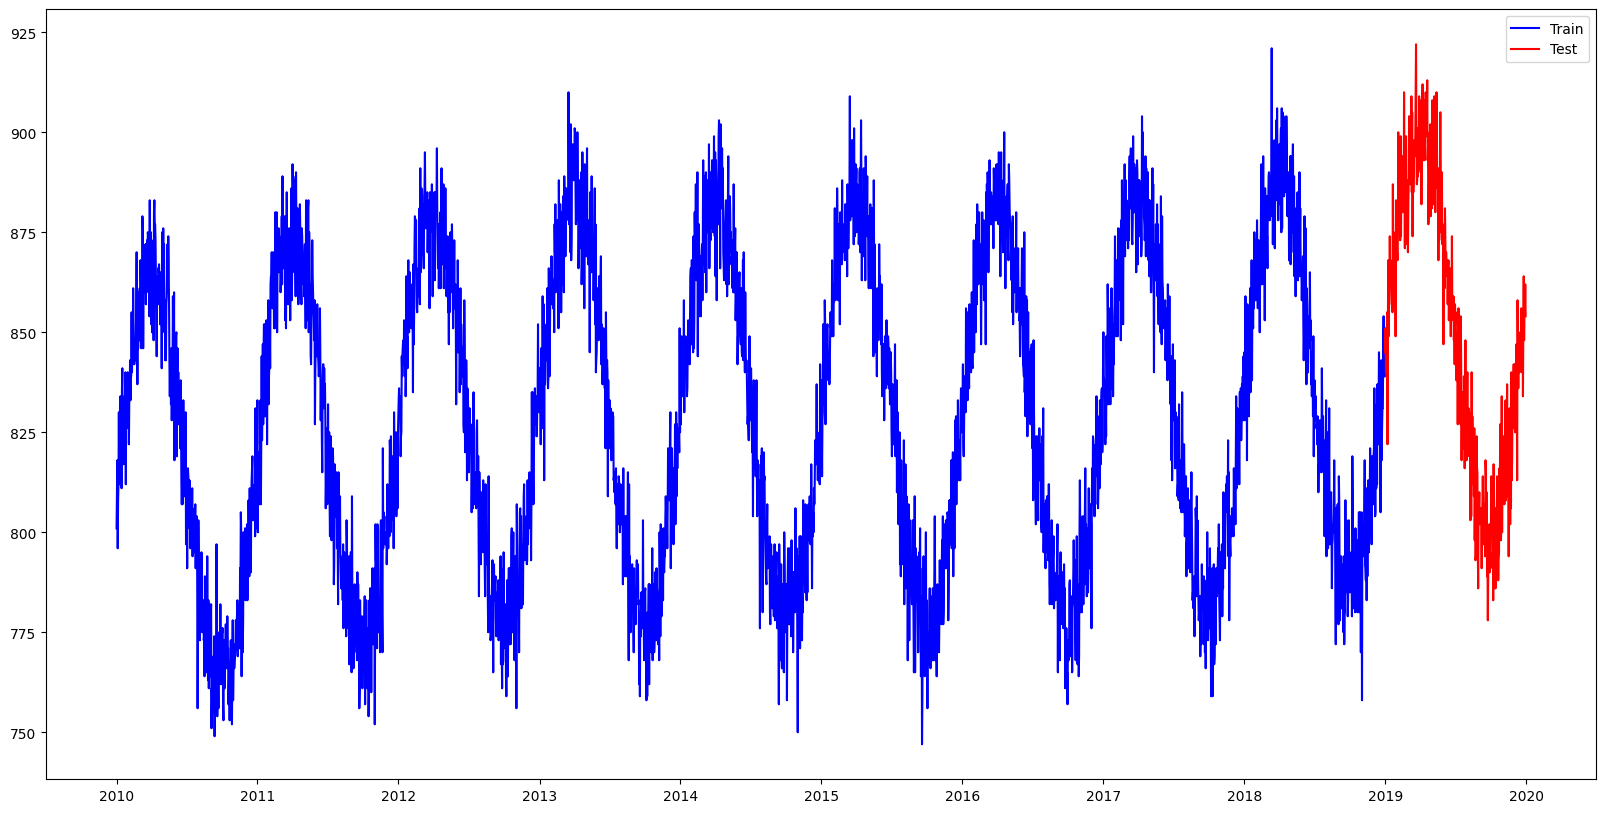

In [28]:
plt.figure(figsize=(20,10))
plt.plot(tdf,color='blue',label='Train')
plt.plot(tedf,color='red',label='Test')
plt.legend()
plt.show()

In [29]:
# importing 
from statsmodels.tsa.stattools import adfuller,pacf,acf
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

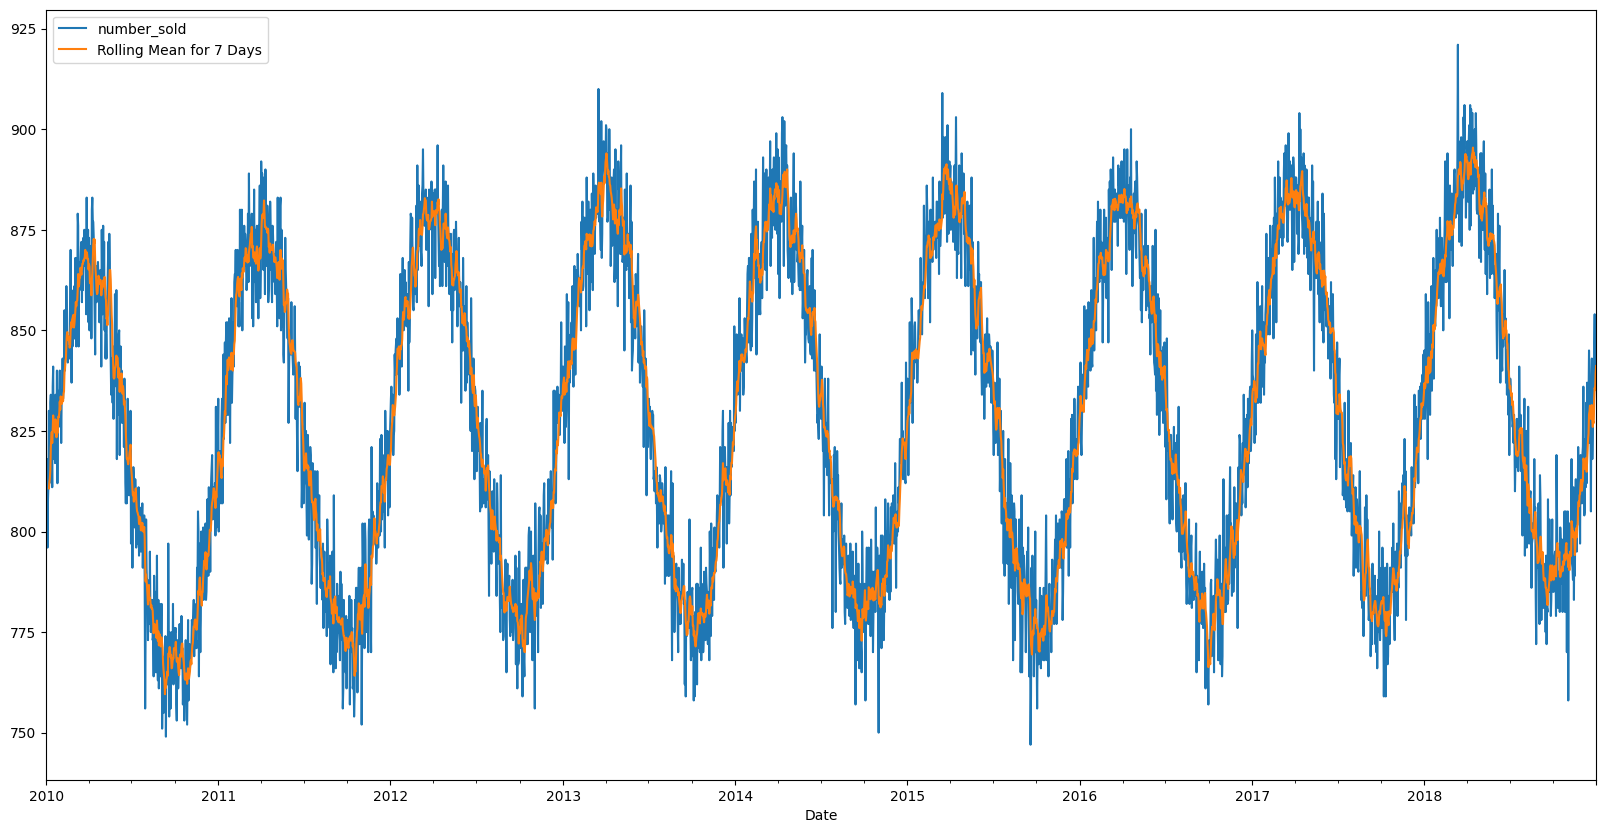

In [30]:
plt.figure(figsize=(20,10))
tdf['number_sold'].plot()
tdf['number_sold'].rolling(7).mean().plot(label='Rolling Mean for 7 Days')
#tdf['number_sold'].rolling(90).mean().plot(label='Rolling Mean for 90 Days')
#tdf['number_sold'].rolling(180).mean().plot(label='Rolling Mean for 180 Days')
#tdf['number_sold'].rolling(365).mean().plot(label='Rolling Mean for 365 Days')
plt.legend()
plt.show()

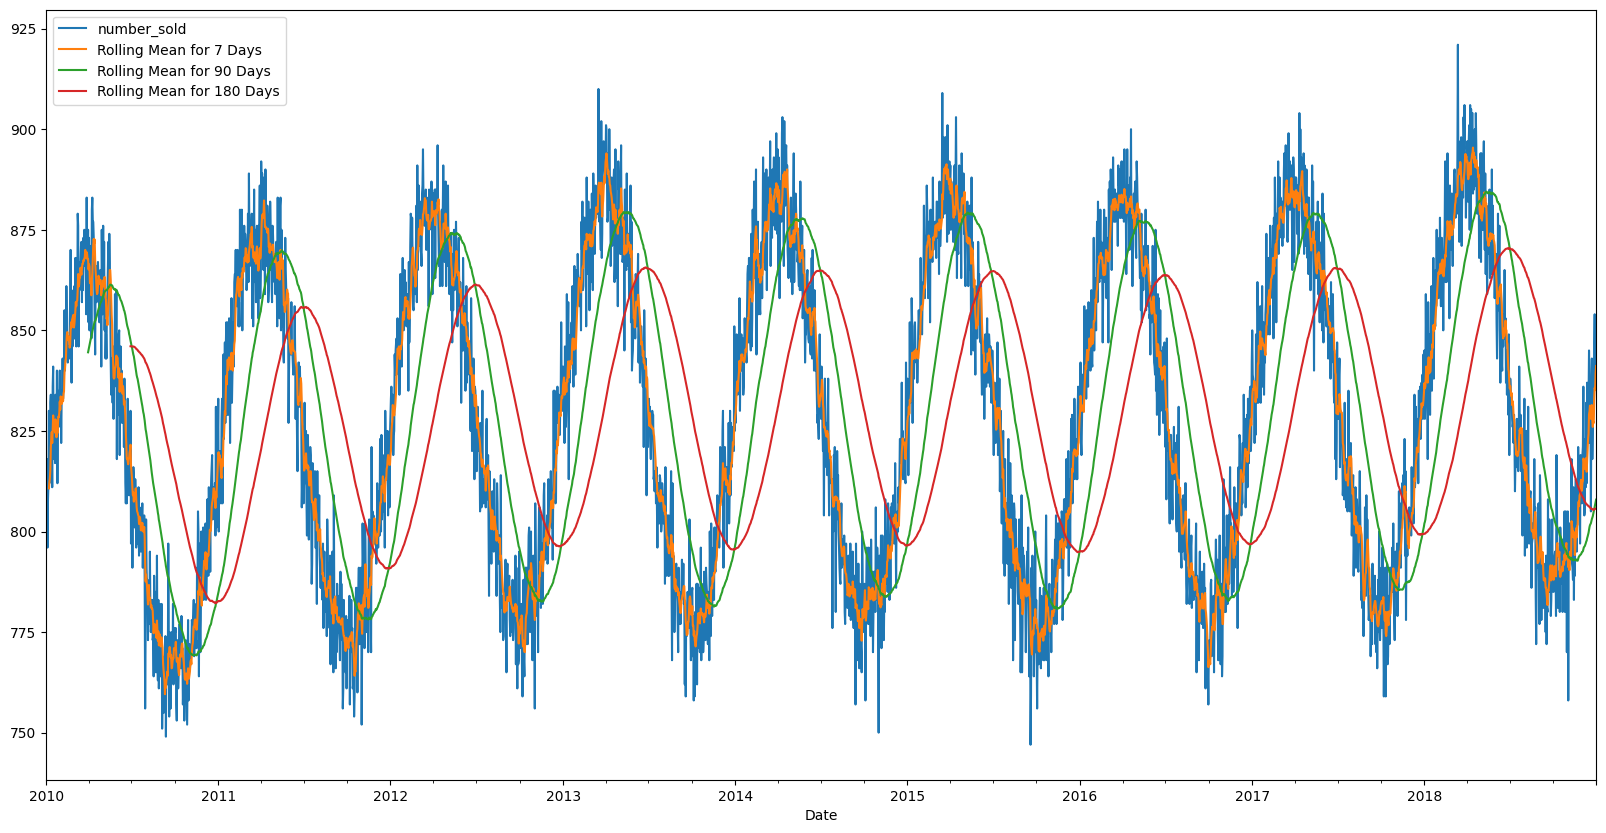

In [32]:
plt.figure(figsize=(20,10))
tdf['number_sold'].plot()
tdf['number_sold'].rolling(7).mean().plot(label='Rolling Mean for 7 Days')
tdf['number_sold'].rolling(90).mean().plot(label='Rolling Mean for 90 Days')
tdf['number_sold'].rolling(180).mean().plot(label='Rolling Mean for 180 Days')
#tdf['number_sold'].rolling(365).mean().plot(label='Rolling Mean for 365 Days')
plt.legend()
plt.show()

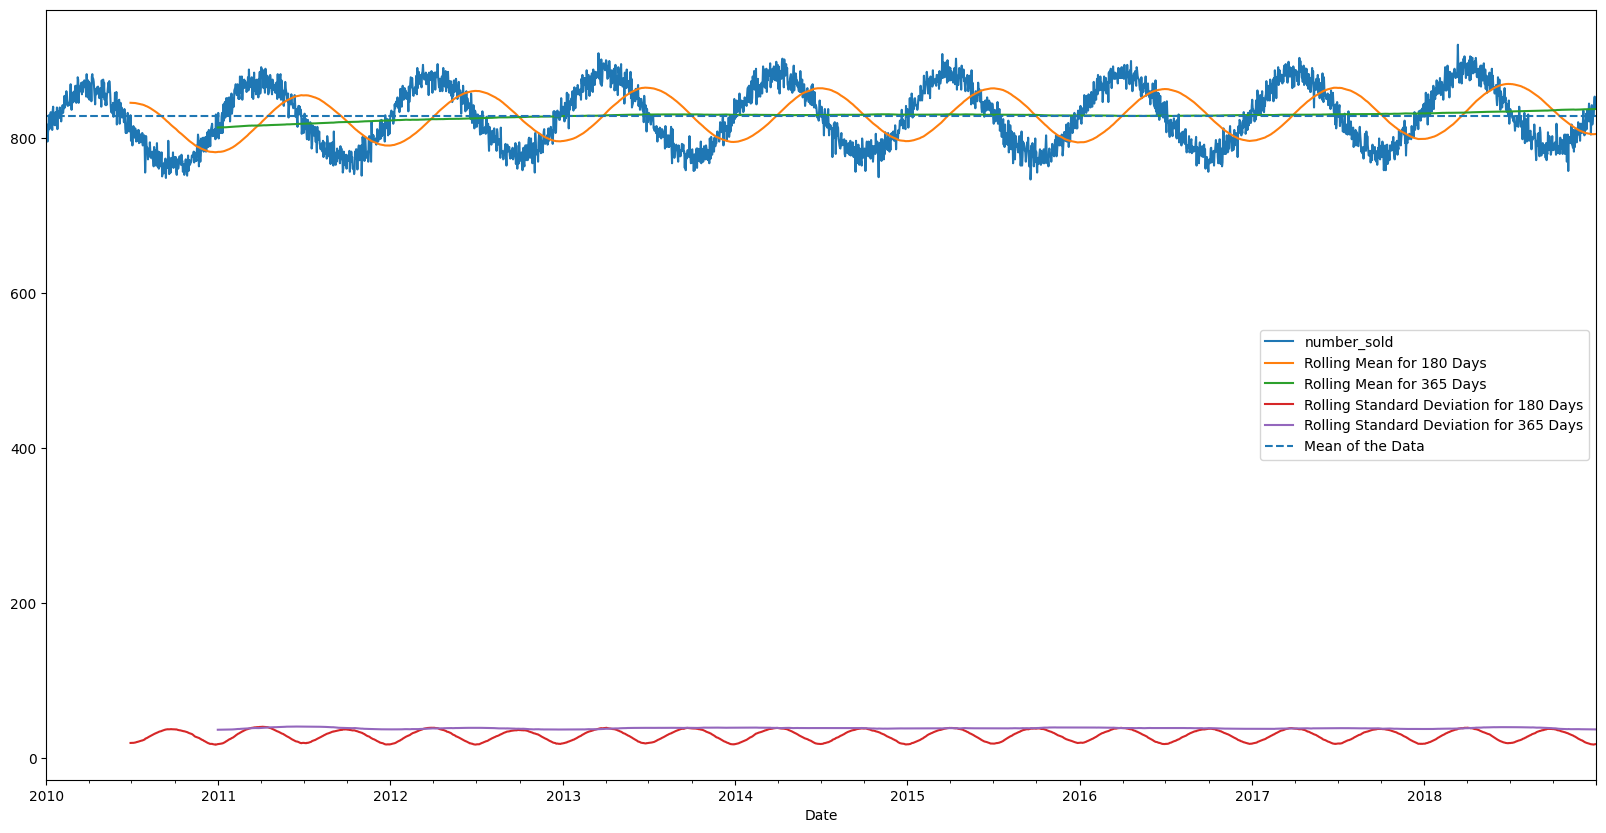

In [33]:
plt.figure(figsize=(20,10))
tdf['number_sold'].plot()
tdf['number_sold'].rolling(180).mean().plot(label='Rolling Mean for 180 Days')
tdf['number_sold'].rolling(365).mean().plot(label='Rolling Mean for 365 Days')
tdf['number_sold'].rolling(180).std().plot(label='Rolling Standard Deviation for 180 Days')
tdf['number_sold'].rolling(365).std().plot(label='Rolling Standard Deviation for 365 Days')
plt.axhline(tdf['number_sold'].mean(),linestyle='--',label='Mean of the Data')
plt.legend()
plt.show()

In [34]:
result = adfuller(tdf['number_sold'])

# Display the results
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# Interpret the p-value
if result[1] <= 0.05:
    print("The series is likely stationary (reject null hypothesis).")
else:
    print("The series is likely non-stationary (fail to reject null hypothesis).")

ADF Statistic: -5.051464907455929
p-value: 1.7536429088010992e-05
Critical Values: {'1%': np.float64(-3.4323593525669414), '5%': np.float64(-2.8624278120183573), '10%': np.float64(-2.567242601304915)}
The series is likely stationary (reject null hypothesis).


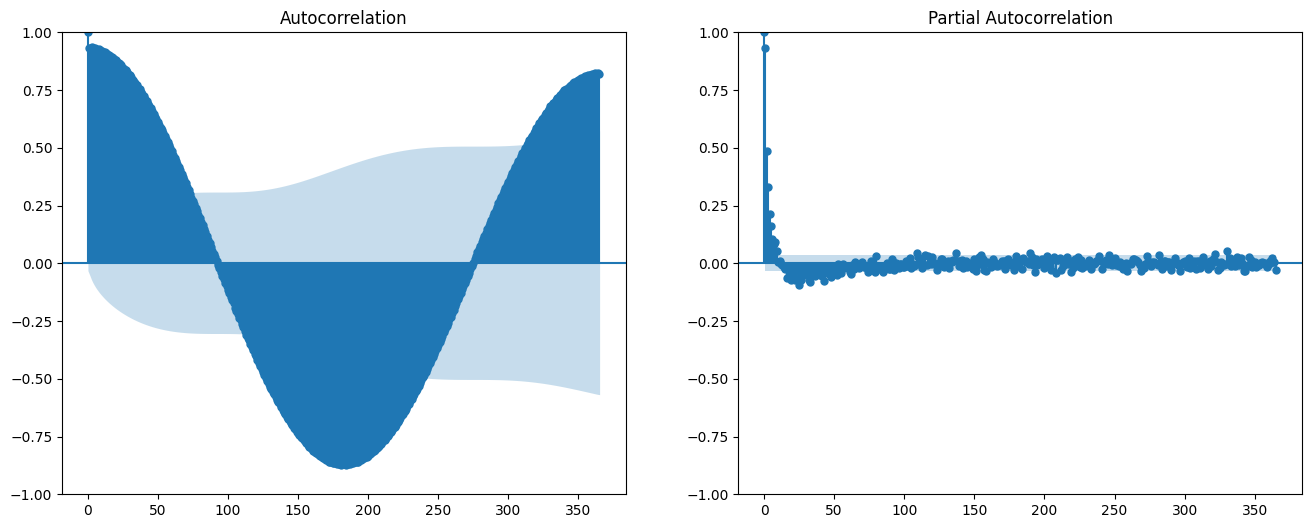

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(tdf['number_sold'], lags=365, ax=axes[0])  # ACF plot
plot_pacf(tdf['number_sold'], lags=365, ax=axes[1])  # PACF plot
plt.show()

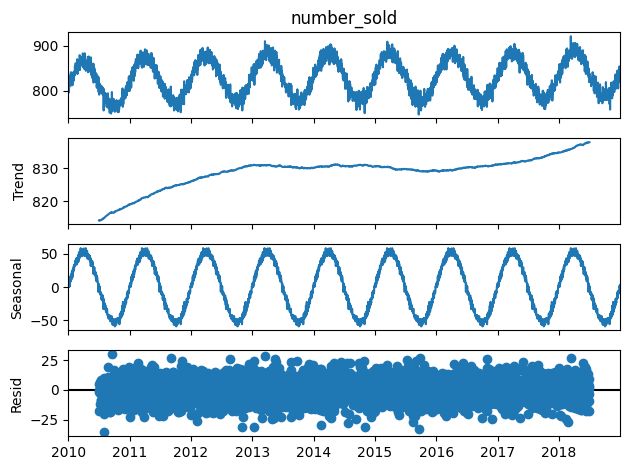

In [36]:
decomposition = seasonal_decompose(tdf['number_sold'], model='additive', period=365)
decomposition.plot()
plt.show()